# Influence of Artificial Intelligence Feedback on Human Confidence and Decision Accuracy in Complex Problem-Solving Tasks

In [9]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest

packages to install
- pandas, numpy, matplotlib, scipy, sklearn (use scikit-learn), statsmodel, ast, seaborn

install all in the terminal using
- pip install pandas numpy matplotlib scipy scikit-learn statsmodel ast seaborn

N:B no commas.

## Preprocessing

### Loading the datasets and renaming columns

In [10]:
folder_path = r"..\data\chess_data\Data\Data"
all_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.csv')]

dfs = []

for file in all_files:
    df = pd.read_csv(file)
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

combined_df.to_csv(r"..\data\results\chess\initial_df.csv", index=False)

In [11]:
columns_renaming = {
                    "bmove1":"initial_move",
                    "aisugg":"ai_suggestion",
                    "bmove2":"final_move",
                    "wmove": "opponent_move",
                    "multiPV": "ai_suggestion_ranking",
                    }
combined_df = combined_df.rename(columns=columns_renaming)
combined_df.to_csv(r"..\data\results\chess\initial_df.csv", index=False)

In [12]:
num_cols = ['ai_suggestion_ranking', 'feedback1', 'feedback2', 'selfconf', 'aiconf']
cat_cols = [
        'opponent_move', 'allgoodmoves', 'initial_move', 'ai_suggestion',
        'final_move', 'fen before white move', 'fen before black move'
]

### Functions

In [13]:
def treat_missing_values(df: pd.DataFrame):
    clean_df = df[~df['opponent_move'].isin(['Score','Score '])] # removing rows with overall game score from
    clean_df = clean_df.reset_index(drop=True)
    clean_df.loc[:, cat_cols] = clean_df.loc[:, cat_cols].fillna("Unknown")

    for col in num_cols:
        clean_df.loc[:, col] = clean_df.loc[:, col].fillna(clean_df[col].median())
    
    return clean_df


def feature_engineering(df: pd.DataFrame):
    df = df.copy()

    df['initial_move'] = df['initial_move'].astype(str).str.lower().str.strip()
    df['final_move'] = df['final_move'].astype(str).str.lower().str.strip()
    df['ai_suggestion'] = df['ai_suggestion'].astype(str).str.lower().str.strip()
    df['allgoodmoves'] = df['allgoodmoves'].astype(str).str.lower()

    df['confidence_shift'] = df['aiconf'] - df['selfconf']
    df['pre_accuracy'] = df.apply(
        lambda row: 1 if row['initial_move'] in row['allgoodmoves'] else 0,
        axis=1
    )
    df['post_accuracy'] = df.apply(
        lambda row: 1 if row['final_move'] in row['allgoodmoves'] else 0,
        axis=1
    )
    df['accuracy_delta'] = df['post_accuracy'] - df['pre_accuracy']
    df['reliance_index'] = (df['final_move'] == df['ai_suggestion']).astype(int)
    
    return df


def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    
    return outliers, lower, upper


def find_outliers_zscore(df, column, threshold=3):
    series = df[column].dropna()
    z_scores = np.abs(stats.zscore(series))
    outliers = df.loc[series.index[z_scores > threshold]]
    return outliers


def find_outliers_iforest(df, column):
    iso = IsolationForest(contamination='auto', random_state=42)
    preds = iso.fit_predict(df[[column]].dropna())
    outliers = df.loc[df[[column]].dropna().index[preds == -1]]
    return outliers


def outlier_summary(df):
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    summary = {}

    for col in num_cols:
        series = df[col].dropna()
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = series[(series < lower) | (series > upper)]
        pct = round(len(outliers) / len(series) * 100, 2)

        summary[col] = {
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Lower Bound': lower,
            'Upper Bound': upper,
            'Outlier Count': len(outliers),
            'Outlier %': pct
        }

    return pd.DataFrame(summary).T


def plot_boxplots(df):
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    n = len(num_cols)

    plt.figure(figsize=(12, 2 * n))
    for i, col in enumerate(num_cols, 1):
        plt.subplot(n, 1, i)
        df[col].plot(kind='box')
        plt.title(f'Boxplot for {col}')
        plt.xlabel('')
    plt.tight_layout()
    plt.show()


In [14]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   opponent_move          3500 non-null   object 
 1   allgoodmoves           3500 non-null   object 
 2   initial_move           3300 non-null   object 
 3   ai_suggestion          3300 non-null   object 
 4   ai_suggestion_ranking  3300 non-null   float64
 5   final_move             3300 non-null   object 
 6   feedback1              3300 non-null   float64
 7   feedback2              3300 non-null   float64
 8   selfconf               3400 non-null   float64
 9   aiconf                 3400 non-null   float64
 10  fen before white move  3300 non-null   object 
 11  fen before black move  3300 non-null   object 
dtypes: float64(5), object(7)
memory usage: 337.6+ KB


### Treating Missing Values

In [15]:
reviewed_df = combined_df[~combined_df['opponent_move'].isin(['Score','Score '])] # removing rows with overall game score from
reviewed_df = reviewed_df.reset_index(drop=True)

for col in num_cols:
    print(reviewed_df[col].value_counts())
reviewed_df.describe()
reviewed_df.info()

ai_suggestion_ranking
1.0    1700
7.0    1600
Name: count, dtype: int64
feedback1
-5.0    2304
 5.0     996
Name: count, dtype: int64
feedback2
-5.0    1781
 5.0    1519
Name: count, dtype: int64
selfconf
0.50    1479
0.25     798
0.75     724
0.00     278
1.00     121
Name: count, dtype: int64
aiconf
0.50    1298
0.75    1002
0.25     610
1.00     266
0.00     224
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   opponent_move          3300 non-null   object 
 1   allgoodmoves           3300 non-null   object 
 2   initial_move           3300 non-null   object 
 3   ai_suggestion          3300 non-null   object 
 4   ai_suggestion_ranking  3300 non-null   float64
 5   final_move             3300 non-null   object 
 6   feedback1              3300 non-null   float64
 7   feedback2              330

In [16]:
reviewed_df.loc[:, cat_cols] = reviewed_df.loc[:, cat_cols].fillna("unknown") 

for col in num_cols:
    reviewed_df.loc[:, col] = reviewed_df.loc[:, col].fillna(reviewed_df[col].median())
reviewed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   opponent_move          3400 non-null   object 
 1   allgoodmoves           3400 non-null   object 
 2   initial_move           3400 non-null   object 
 3   ai_suggestion          3400 non-null   object 
 4   ai_suggestion_ranking  3400 non-null   float64
 5   final_move             3400 non-null   object 
 6   feedback1              3400 non-null   float64
 7   feedback2              3400 non-null   float64
 8   selfconf               3400 non-null   float64
 9   aiconf                 3400 non-null   float64
 10  fen before white move  3400 non-null   object 
 11  fen before black move  3400 non-null   object 
dtypes: float64(5), object(7)
memory usage: 318.9+ KB


### Feature Engineering

In [17]:
reviewed_df
new_df = feature_engineering(reviewed_df)


### Outlier Identification

 OUTLIER SUMMARY (IQR METHOD)


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
ai_suggestion_ranking,1.00,7.00,6.00,-8.000,16.000,0.0,0.00
feedback1,-5.00,5.00,10.00,-20.000,20.000,0.0,0.00
feedback2,-5.00,5.00,10.00,-20.000,20.000,0.0,0.00
selfconf,0.25,0.50,0.25,-0.125,0.875,121.0,3.56
aiconf,0.50,0.75,0.25,0.125,1.125,224.0,6.59
confidence_shift,0.00,0.25,0.25,-0.375,0.625,352.0,10.35
pre_accuracy,0.00,1.00,1.00,-1.500,2.500,0.0,0.00
post_accuracy,0.00,1.00,1.00,-1.500,2.500,0.0,0.00
accuracy_delta,0.00,1.00,1.00,-1.500,2.500,0.0,0.00
reliance_index,0.00,1.00,1.00,-1.500,2.500,0.0,0.00


BOXPLOTS FOR VISUAL INSPECTION


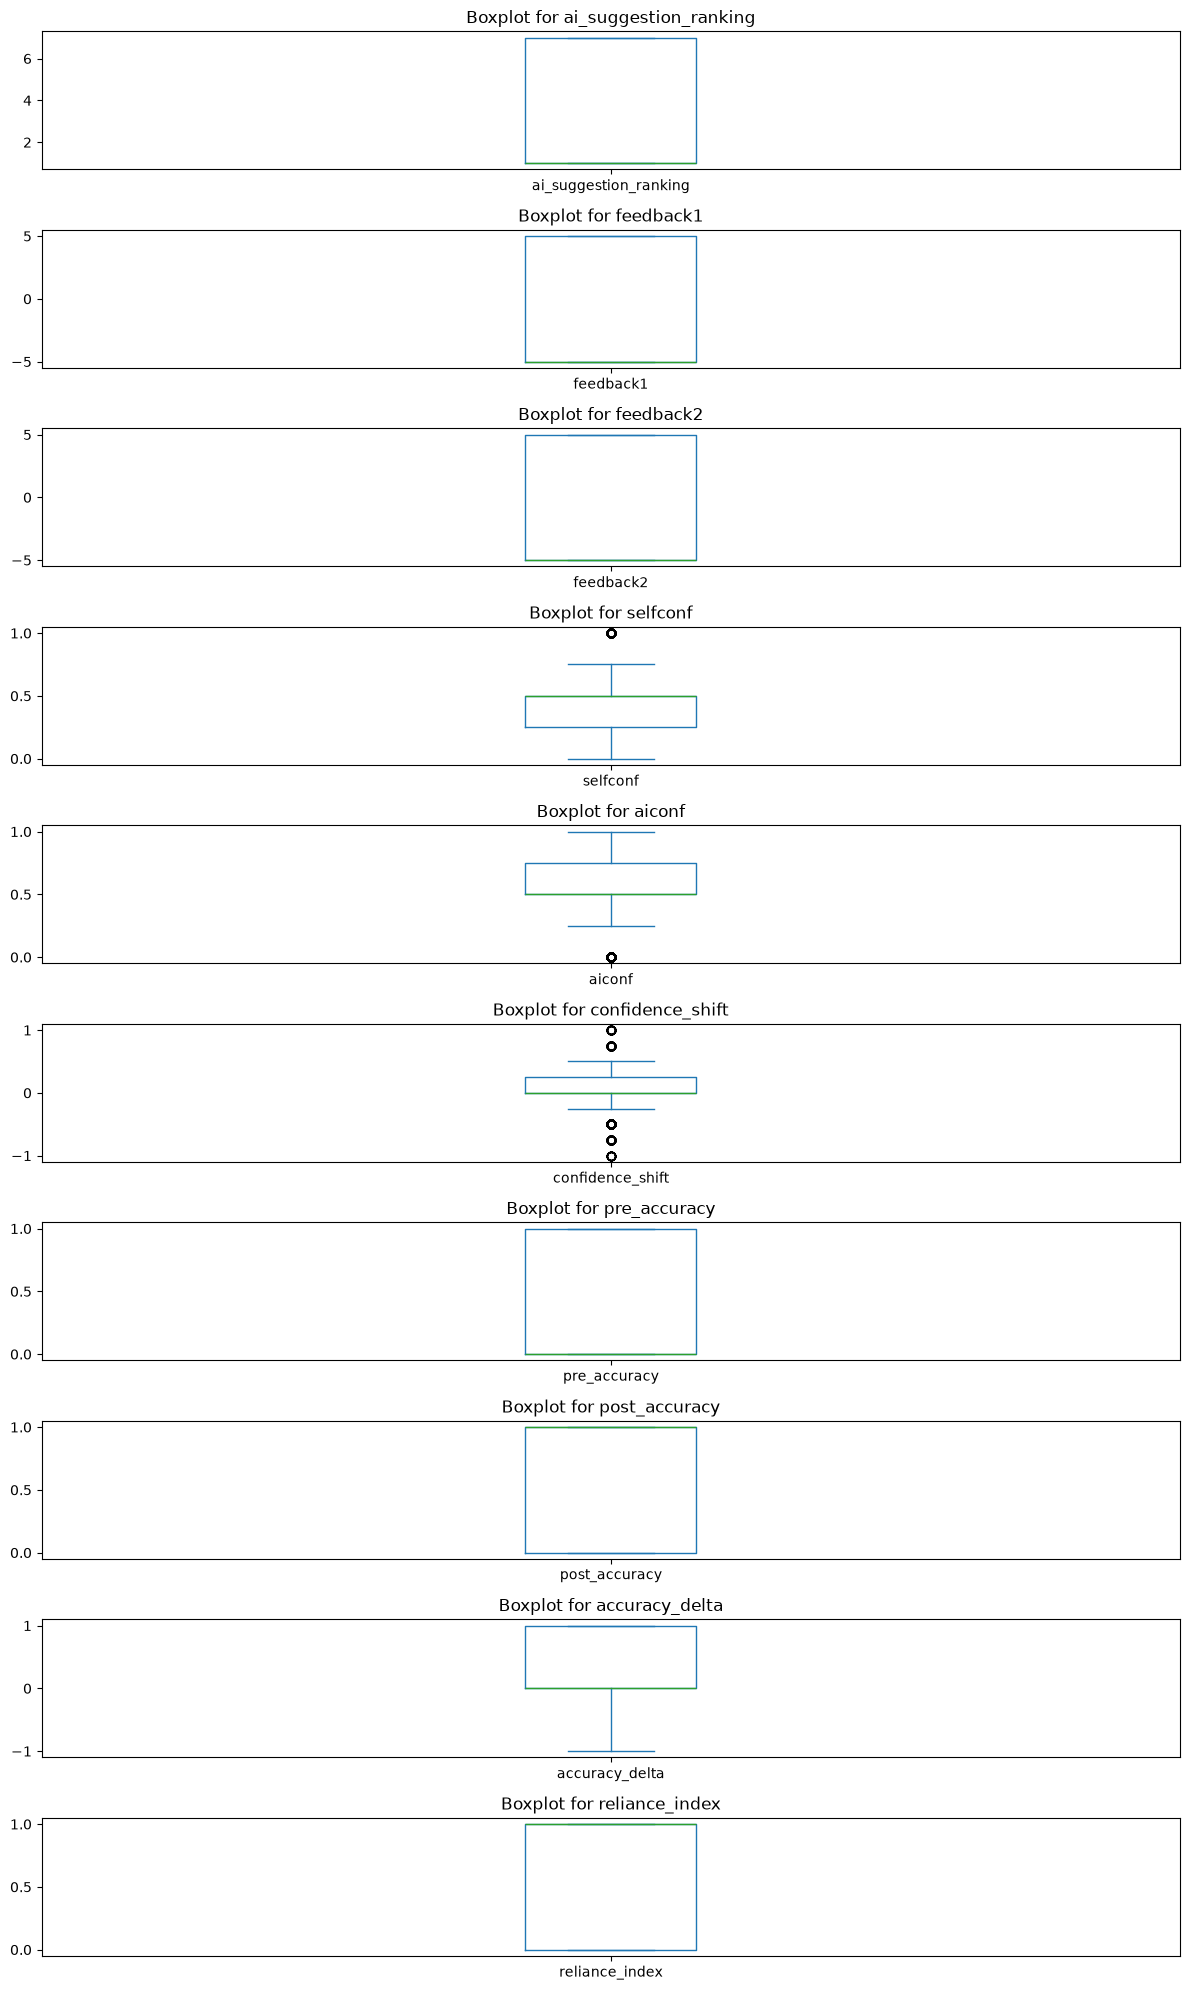

INTERPRETATION:
 • ai_suggestion_ranking: 0.0% outliers — ✔️ acceptable
 • feedback1: 0.0% outliers — ✔️ acceptable
 • feedback2: 0.0% outliers — ✔️ acceptable
 • selfconf: 3.56% outliers — ✔️ acceptable
 • aiconf: 6.59% outliers — investigate
 • confidence_shift: 10.35% outliers — investigate
 • pre_accuracy: 0.0% outliers — ✔️ acceptable
 • post_accuracy: 0.0% outliers — ✔️ acceptable
 • accuracy_delta: 0.0% outliers — ✔️ acceptable
 • reliance_index: 0.0% outliers — ✔️ acceptable
Analysis complete.


In [ ]:
print(" OUTLIER SUMMARY (IQR METHOD)")
summary_df = outlier_summary(new_df)
display(summary_df)

print("BOXPLOTS FOR VISUAL INSPECTION")
plot_boxplots(new_df)

print("INTERPRETATION:")
for col in summary_df.index:
    pct = summary_df.loc[col, 'Outlier %']
    print(f" • {col}: {pct}% outliers — "
          f"{'investigate' if pct > 5 else '✔️ acceptable'}")


## EDA

### Functions

In [19]:
def correlation_heatmap(df: pd.DataFrame):

    corr_matrix = df[num_cols].corr()

    print("Correlation matrix:")
    plt.figure(figsize=(10, 8))
    im = plt.imshow(corr_matrix, interpolation="nearest")
    plt.colorbar(im)

    plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
    plt.yticks(range(len(num_cols)), num_cols)
    plt.title("Correlation Heatmap of Key Behavioural Variables")

    for i in range(len(num_cols)):
        for j in range(len(num_cols)):
            value = corr_matrix.iloc[i, j]
            plt.text(j, i, f"{value:.2f}",
                    ha="center", va="center", color="black")
    plt.tight_layout()
    plt.show()

### Confidence and Accuracy Distribution

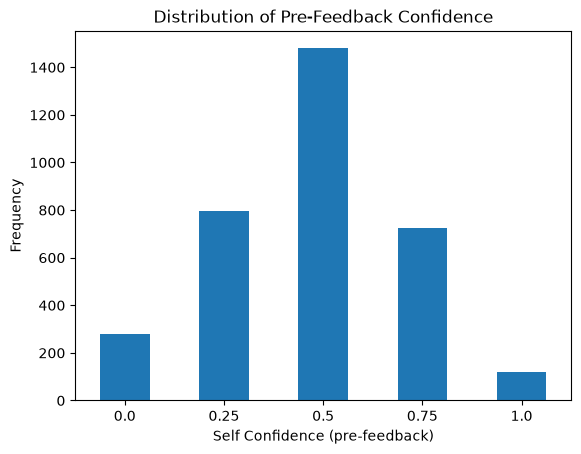

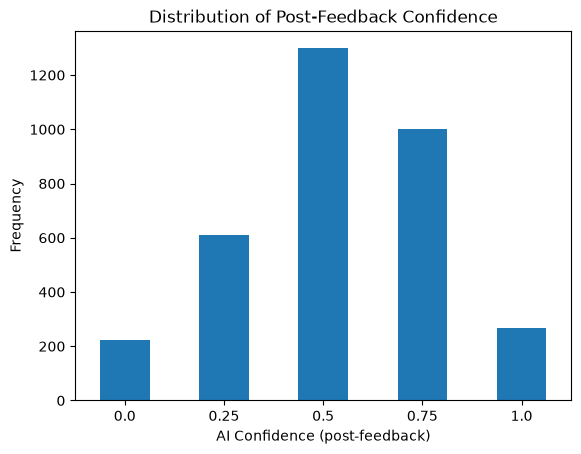

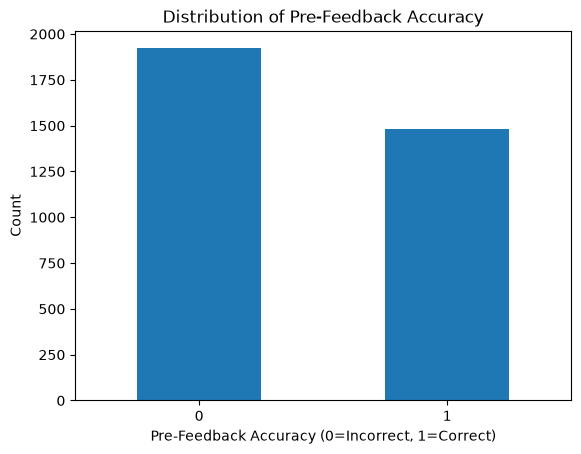

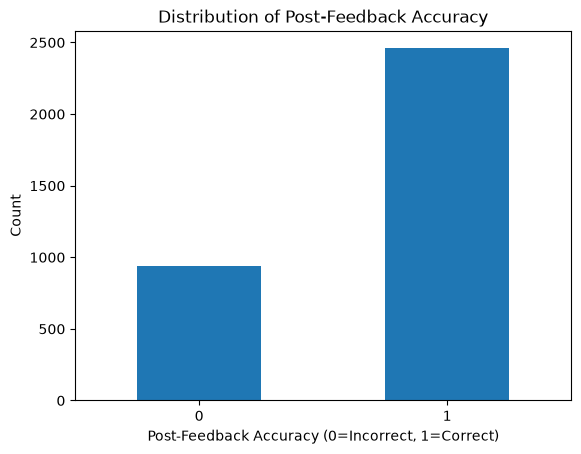

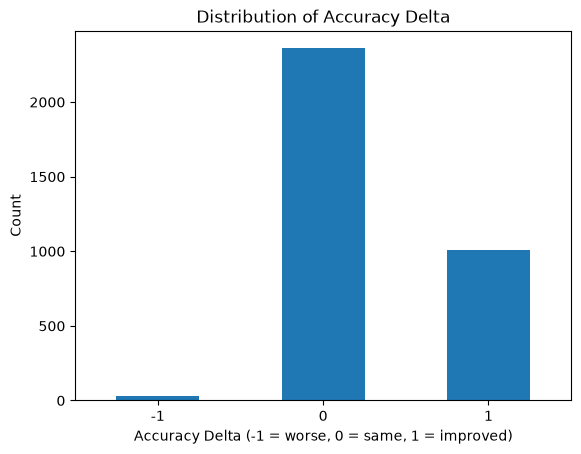

In [20]:
new_df

# Plots: Confidence distributions
plt.figure()
new_df['selfconf'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Self Confidence (pre-feedback)")
plt.ylabel("Frequency")
plt.title("Distribution of Pre-Feedback Confidence")
plt.xticks(rotation=0)
plt.show()

plt.figure()
new_df["aiconf"].value_counts().sort_index().plot(kind='bar')
plt.xlabel("AI Confidence (post-feedback)")
plt.ylabel("Frequency")
plt.title("Distribution of Post-Feedback Confidence")
plt.xticks(rotation=0)
plt.show()


# Plots: Accuracy distributions
plt.figure()
new_df['pre_accuracy'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Pre-Feedback Accuracy (0=Incorrect, 1=Correct)")
plt.ylabel("Count")
plt.title("Distribution of Pre-Feedback Accuracy")
plt.xticks([0, 1], rotation=0)
plt.show()

plt.figure()
new_df['post_accuracy'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Post-Feedback Accuracy (0=Incorrect, 1=Correct)")
plt.ylabel("Count")
plt.title("Distribution of Post-Feedback Accuracy")
plt.xticks([0, 1], rotation=0)
plt.show()

plt.figure()
new_df['accuracy_delta'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Accuracy Delta (-1 = worse, 0 = same, 1 = improved)")
plt.ylabel("Count")
plt.title("Distribution of Accuracy Delta")
plt.xticks(rotation=0)
plt.show()


In [27]:
new_df

,opponent_move,allgoodmoves,initial_move,ai_suggestion,ai_suggestion_ranking,final_move,feedback1,feedback2,selfconf,aiconf,fen before white move,fen before black move,confidence_shift,pre_accuracy,post_accuracy,accuracy_delta,reliance_index
0,unknown,unknown,unknown,unknown,1.0,unknown,-5.0,-5.0,0.50,0.75,unknown,unknown,0.25,1,1,0,1
1,c4d5,"[[599, 437, 437, 435, 354, -53, -68], ['g4h4',...",e4f6,g4h4,1.0,g4h4,-5.0,5.0,0.25,0.75,rn5k/1p4b1/pr1p4/2pPpp2/2b1N1Q1/6P1/PP1N1P1P/R...,rn5k/1p4b1/pr1p4/2pbpp2/4N1Q1/6P1/PP1N1P1P/R5K...,0.50,0,1,1,1
2,c3a1,"[[1072, 620, 620, 86, -40, -40, -282], ['f3f6'...",h1h2,f3h5,7.0,h1h2,-5.0,-5.0,0.25,0.50,r5rk/2p1Np2/3p3P/4p1P1/4P3/2qnPQK1/8/R6R b - -...,r5rk/2p1Np2/3p3P/4p1P1/4P3/3nPQK1/8/q6R w - - 1 0,0.25,0,0,0,0
3,c8g4,"[[823, 361, 361, 150, 67, -27, -59], ['f3f8', ...",h6f8,f3f8,1.0,f3g3,-5.0,-5.0,0.00,0.50,rnb3k1/ppp4p/3b3B/3Pp3/2BP4/4KRp1/PPP3q1/RN1Q4...,rn4k1/ppp4p/3b3B/3Pp3/2BP2b1/4KRp1/PPP3q1/RN1Q...,0.50,0,0,0,0
4,c8c7,"[[898, 32, 32, -53, -364, -447, -477], ['b6a6'...",b6c6,b6a6,1.0,b6a6,5.0,5.0,0.00,0.75,2k4r/1r1q2pp/1Rp2p2/1p6/8/Q7/P4PPP/2R3K1 b - -...,7r/1rkq2pp/1Rp2p2/1p6/8/Q7/P4PPP/2R3K1 w - - 1 0,0.75,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3395,d8a5,"[[342, 217, 15, 15, -49, -73, -104], ['f2f3', ...",g6e8,f2f3,1.0,g6e8,-5.0,-5.0,0.50,0.25,r2qrk2/p5p1/2b1p1Q1/1p1pP3/2p1nB2/2P1P3/PP3P2/...,r3rk2/p5p1/2b1p1Q1/qp1pP3/2p1nB2/2P1P3/PP3P2/2...,-0.25,0,0,0,0
3396,a8a7,"[[507, 210, 13, -59, -107, -109, -438], ['h7g6...",f4f8,h7g6,1.0,h7g8,-5.0,-5.0,0.50,0.25,r3r3/7B/2p1b3/ppk5/5R2/P2P3p/1PP4R/1K6 b - - 0 1,4r3/r6B/2p1b3/ppk5/5R2/P2P3p/1PP4R/1K6 w - - 1 0,-0.25,0,0,0,0
3397,b4c3,"[[161, 156, 100, -15, -213, -253, -254], ['a1b...",h6h7,a1b1,1.0,h6h7,-5.0,-5.0,0.50,0.25,r1r3k1/pp1q1p1p/4nBpQ/3pP3/1b5P/3B4/P1N3P1/R2K...,r1r3k1/pp1q1p1p/4nBpQ/3pP3/7P/2bB4/P1N3P1/R2K3...,-0.25,0,0,0,0
3398,h7g6,"[[20, 18, 3, 0, -15, -31, -49], ['h2h3', 'h2h3...",f3f5,e3d2,7.0,f3f5,-5.0,-5.0,0.50,0.00,4r3/6kp/ppr1b1P1/3p4/3Pq3/3nBR2/PP4QP/6RK b - ...,4r3/6k1/ppr1b1p1/3p4/3Pq3/3nBR2/PP4QP/6RK w - ...,-0.50,0,0,0,0


EFFECT OF FEEDBACK TYPE — SUMMARY TABLE


,selfconf,aiconf,pre_accuracy,post_accuracy,confidence_shift,accuracy_delta
feedback2,,,,,,
-5.0,0.422116,0.488038,0.283892,0.499203,0.065922,0.215311
5.0,0.532587,0.593153,0.622120,1.000000,0.060566,0.377880


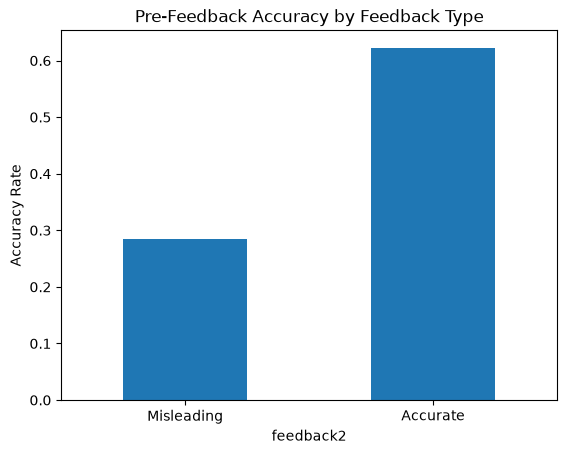

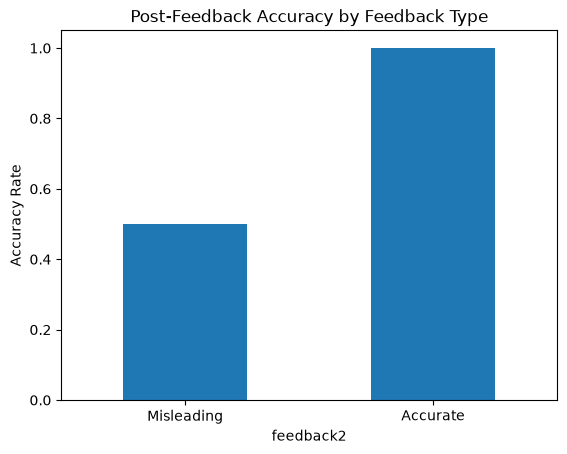

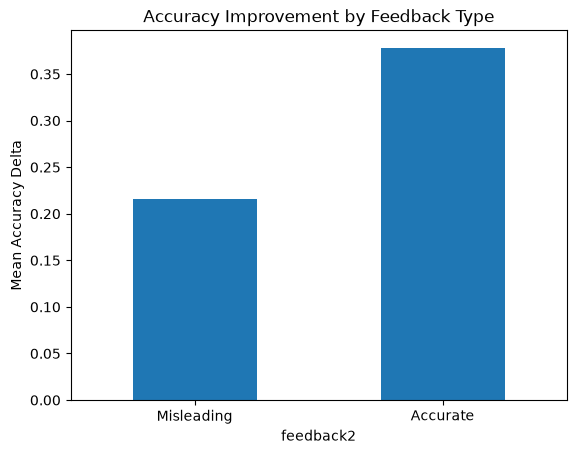

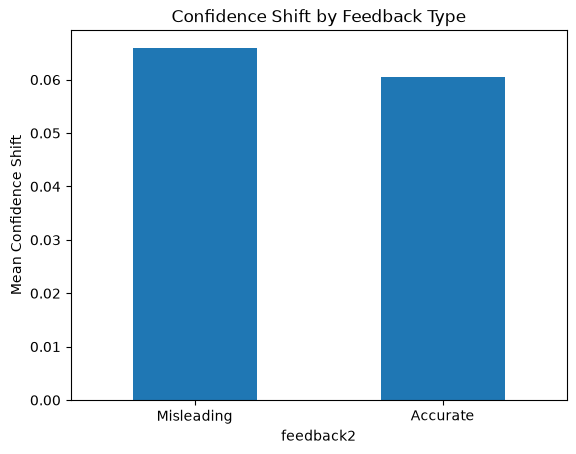

In [21]:
# FEEDBACK TYPE CLASSIFICATION

# GROUPED SUMMARY STATISTICS
summary = new_df.groupby("feedback2")[[
    "selfconf", "aiconf",
    "pre_accuracy", "post_accuracy",
    "confidence_shift", "accuracy_delta"
]].mean().rename(index={0: "Misleading", 1: "Accurate"})

print("EFFECT OF FEEDBACK TYPE — SUMMARY TABLE")
display(summary)

# BAR PLOTS: PRE vs POST ACCURACY
plt.figure()
new_df.groupby("feedback2")["pre_accuracy"].mean().plot(kind="bar")
plt.title("Pre-Feedback Accuracy by Feedback Type")
plt.ylabel("Accuracy Rate")
plt.xticks([0,1], ["Misleading", "Accurate"], rotation=0)
plt.show()

plt.figure()
new_df.groupby("feedback2")["post_accuracy"].mean().plot(kind="bar")
plt.title("Post-Feedback Accuracy by Feedback Type")
plt.ylabel("Accuracy Rate")
plt.xticks([0,1], ["Misleading", "Accurate"], rotation=0)
plt.show()


# BAR PLOT: ACCURACY DELTA
plt.figure()
new_df.groupby("feedback2")["accuracy_delta"].mean().plot(kind="bar")
plt.title("Accuracy Improvement by Feedback Type")
plt.ylabel("Mean Accuracy Delta")
plt.xticks([0,1], ["Misleading", "Accurate"], rotation=0)
plt.show()


# BAR PLOT: CONFIDENCE SHIFT
plt.figure()
new_df.groupby("feedback2")["confidence_shift"].mean().plot(kind="bar")
plt.title("Confidence Shift by Feedback Type")
plt.ylabel("Mean Confidence Shift")
plt.xticks([0,1], ["Misleading", "Accurate"], rotation=0)
plt.show()


### Correlation Heatmap

Correlation matrix:


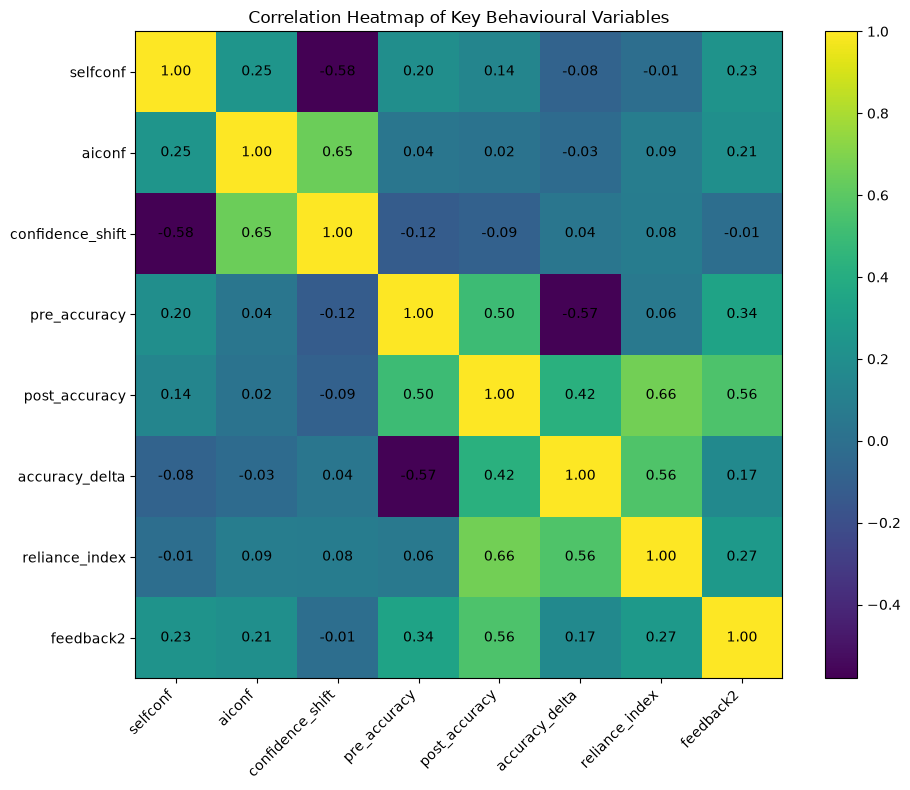

In [22]:
num_cols = [
    "selfconf", "aiconf", "confidence_shift",
    "pre_accuracy", "post_accuracy", "accuracy_delta",
    "reliance_index", "feedback2"
]

correlation_heatmap(new_df)


## Hypothesis Testing

### Functions

In [23]:
import pandas as pd
import numpy as np
import ast
import statsmodels.api as sm
from scipy.stats import pearsonr

def convert_float(data):
    return float(np.round(data, 2))


def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    s1, s2 = g1.std(), g2.std()
    pooled_sd = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_sd


def extract_all_moves(val):
    if pd.isna(val):
        return []
    try:
        obj = ast.literal_eval(val)
        if not isinstance(obj, list) or len(obj) != 2:
            return []
        scores, moves = obj
        moves_clean = [str(m).lower().strip() for m in moves]
        return moves_clean
    except Exception:
        return []
    

def extract_positive_moves(val):
    if pd.isna(val):
        return []
    try:
        obj = ast.literal_eval(val)
        if not isinstance(obj, list) or len(obj) != 2:
            return []
        scores, moves = obj
        positive = [
            str(m).lower().strip()
            for s, m in zip(scores, moves)
            if isinstance(s, (int, float)) and s > 0
        ]
        return positive
    except Exception:
        return []
    

def extract_best_move(val):
    if pd.isna(val):
        return None
    try:
        obj = ast.literal_eval(val)
        if not isinstance(obj, list) or len(obj) != 2:
            return None
        scores, moves = obj
        scores = [float(s) if isinstance(s, (int, float)) else None for s in scores]
        if len(scores) == 0:
            return None
        best_idx = int(np.argmax(scores))
        best_move = str(moves[best_idx]).lower().strip()
        return best_move
    except Exception:
        return None

### H1 (paired t-test)  AI feedback increases accuracy

In [24]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(new_df["pre_accuracy"], new_df["post_accuracy"])

print("H1: AI feedback increases accuracy")
print("----------------------------------")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")


# Effect Size (Cohen's d for paired samples)
diff = new_df["post_accuracy"] - new_df["pre_accuracy"]
cohens_d_h1 = diff.mean() / diff.std()

print(f"Cohen's d (effect size): {cohens_d_h1:.4f}")

# Mean comparison
print("\nMean pre-feedback accuracy:", convert_float(new_df["pre_accuracy"].mean()))
print("Mean post-feedback accuracy:", convert_float(new_df["post_accuracy"].mean()))
print("Mean improvement:", convert_float(new_df["post_accuracy"].mean() - new_df["pre_accuracy"].mean()))

H1: AI feedback increases accuracy
----------------------------------
T-statistic: -35.5278
P-value: 0.000000
Cohen's d (effect size): 0.6093

Mean pre-feedback accuracy: 0.44
Mean post-feedback accuracy: 0.72
Mean improvement: 0.29


### H2 Misleading feedback reduces confidence

In [25]:
from scipy.stats import ttest_ind
import numpy as np

# Split groups
accurate = new_df[new_df["feedback2"] >=5]
misleading = new_df[new_df["feedback2"] <= -5]

# Post-feedback confidence
t_stat_post, p_value_post = ttest_ind(
    misleading["aiconf"].dropna(),
    accurate["aiconf"].dropna(),
    equal_var=False
)

# Confidence shift
t_stat_shift, p_value_shift = ttest_ind(
    misleading["confidence_shift"].dropna(),
    accurate["confidence_shift"].dropna(),
    equal_var=False
)


# Effect size (Cohen's d)
d_post = cohens_d(misleading["aiconf"].dropna(), accurate["aiconf"].dropna())
d_shift = cohens_d(misleading["confidence_shift"].dropna(), accurate["confidence_shift"].dropna())

res_list = [
    misleading['aiconf'].mean(), accurate['aiconf'].mean(),
    t_stat_post, p_value_post, d_post, misleading['confidence_shift'].mean(),
    accurate['confidence_shift'].mean(), t_stat_shift, p_value_shift, d_shift]



res_dict = {
    "Post-confidence mean (misleading)": misleading["aiconf"].mean(),
    "Post-confidence mean (accurate)": accurate["aiconf"].mean(),
    "Post-feedback accuracy (misleading)": misleading["post_accuracy"].mean(),
    "Post-feedback accuracy (accurate)": accurate["post_accuracy"].mean(),
    "t-stat (post-confidence)": t_stat_post,
    "p-value (post-confidence)": p_value_post,
    "Cohen's d (post-confidence)": d_post,

    "Confidence shift mean (misleading)": misleading["confidence_shift"].mean(),
    "Confidence shift mean (accurate)": accurate["confidence_shift"].mean(),
    "t-stat (confidence shift)": t_stat_shift,
    "p-value (confidence shift)": p_value_shift,
    "Cohen's d (confidence shift)": d_shift
}

result = {key:(convert_float(value)) for (key, value) in res_dict.items()}
result

{'Post-confidence mean (misleading)': 0.49,
 'Post-confidence mean (accurate)': 0.59,
 'Post-feedback accuracy (misleading)': 0.5,
 'Post-feedback accuracy (accurate)': 1.0,
 't-stat (post-confidence)': -12.34,
 'p-value (post-confidence)': 0.0,
 "Cohen's d (post-confidence)": -0.42,
 'Confidence shift mean (misleading)': 0.07,
 'Confidence shift mean (accurate)': 0.06,
 't-stat (confidence shift)': 0.51,
 'p-value (confidence shift)': 0.61,
 "Cohen's d (confidence shift)": 0.02}

### H3 Higher AI reliance reduces independent accuracy

#### Checking if post_accuracy result is from any moves in allgoodmoves list. 
- (i.e if final move in allgoodmoves irrespective of whether positive or negative score.)

In [26]:
import pandas as pd
import numpy as np
import ast
import statsmodels.api as sm
from scipy.stats import pearsonr

df = pd.read_csv("clean_df.csv")

# Clean final move
df["final_clean"] = df["final_move"].astype(str).str.lower().str.strip()

# Extract moves and compute broad post accuracy
df["all_moves"] = df["allgoodmoves"].apply(extract_all_moves)
df["post_accuracy_any"] = df.apply(
    lambda row: 1 if row["final_clean"] in row["all_moves"] else 0,
    axis=1
)

df["reliance_index"] = pd.to_numeric(df["reliance_index"], errors="coerce")
df["post_accuracy_any"] = pd.to_numeric(df["post_accuracy_any"], errors="coerce")

h3_df = df.dropna(subset=["post_accuracy_any", "reliance_index"]).copy()


# Summary table
follow_correct = h3_df[(h3_df["reliance_index"] == 1) & (h3_df["post_accuracy_any"] == 1)].shape[0]
follow_total   = h3_df[h3_df["reliance_index"] == 1].shape[0]

ignore_correct = h3_df[(h3_df["reliance_index"] == 0) & (h3_df["post_accuracy_any"] == 1)].shape[0]
ignore_total   = h3_df[h3_df["reliance_index"] == 0].shape[0]

summary_any = {
    "Total trials": len(h3_df),
    "Followed AI (n)": follow_total,
    "Followed AI AND correct (n)": follow_correct,
    "Followed AI AND correct (%)": round(follow_correct / follow_total * 100, 2) if follow_total > 0 else None,
    "Ignored AI (n)": ignore_total,
    "Ignored AI AND correct (n)": ignore_correct,
    "Ignored AI AND correct (%)": round(ignore_correct / ignore_total * 100, 2) if ignore_total > 0 else None,
}

print("=== Level 1: Broad Accuracy (any engine-approved move) ===")
print(summary_any)


# Pearson correlation
r_any, p_any = pearsonr(h3_df["reliance_index"], h3_df["post_accuracy_any"])
print("\nPearson r:", convert_float(r_any))
print("p-value  :", convert_float(p_any))


# Logistic regression
X = sm.add_constant(h3_df["reliance_index"])
y = h3_df["post_accuracy_any"]

logit_any = sm.Logit(y, X).fit(disp=False)
print("\nLogit model summary:\n")
print(logit_any.summary())

params = logit_any.params
conf = logit_any.conf_int()
conf.columns = ["2.5%", "97.5%"]
or_table_any = np.exp(pd.concat([params, conf], axis=1))
or_table_any.columns = ["OR", "2.5%", "97.5%"]

print("\nOdds ratios (Level 1):")
print(or_table_any)


FileNotFoundError: [Errno 2] No such file or directory: 'clean_df.csv'

In [ ]:
import pandas as pd
import numpy as np
import ast
import statsmodels.api as sm
from scipy.stats import pearsonr


df = pd.read_csv("clean_df.csv")

# Clean final move
df["final_clean"] = df["final_move"].astype(str).str.lower().str.strip()

# Extract positive moves and compute stricter post accuracy
df["positive_moves"] = df["allgoodmoves"].apply(extract_positive_moves)
df["post_accuracy_pos"] = df.apply(
    lambda row: 1 if row["final_clean"] in row["positive_moves"] else 0,
    axis=1
)

df["reliance_index"] = pd.to_numeric(df["reliance_index"], errors="coerce")
df["post_accuracy_pos"] = pd.to_numeric(df["post_accuracy_pos"], errors="coerce")

h3_df = df.dropna(subset=["post_accuracy_pos", "reliance_index"]).copy()


# Summary table
follow_correct = h3_df[(h3_df["reliance_index"] == 1) & (h3_df["post_accuracy_pos"] == 1)].shape[0]
follow_total   = h3_df[h3_df["reliance_index"] == 1].shape[0]

ignore_correct = h3_df[(h3_df["reliance_index"] == 0) & (h3_df["post_accuracy_pos"] == 1)].shape[0]
ignore_total   = h3_df[h3_df["reliance_index"] == 0].shape[0]

summary_pos = {
    "Total trials": len(h3_df),
    "Followed AI (n)": follow_total,
    "Followed AI AND correct (n)": follow_correct,
    "Followed AI AND correct (%)": round(follow_correct / follow_total * 100, 2) if follow_total > 0 else None,
    "Ignored AI (n)": ignore_total,
    "Ignored AI AND correct (n)": ignore_correct,
    "Ignored AI AND correct (%)": round(ignore_correct / ignore_total * 100, 2) if ignore_total > 0 else None,
}

print("=== Level 2: Positive-Only Accuracy (score > 0) ===")
print(summary_pos)


# Pearson correlation
r_pos, p_pos = pearsonr(h3_df["reliance_index"], h3_df["post_accuracy_pos"])
print("\nPearson r:", r_pos)
print("p-value  :", p_pos)


# Logistic regression
X = sm.add_constant(h3_df["reliance_index"])
y = h3_df["post_accuracy_pos"]

logit_pos = sm.Logit(y, X).fit(disp=False)
print("\nLogit model summary:\n")
print(logit_pos.summary())

params = logit_pos.params
conf = logit_pos.conf_int()
conf.columns = ["2.5%", "97.5%"]
or_table_pos = np.exp(pd.concat([params, conf], axis=1))
or_table_pos.columns = ["OR", "2.5%", "97.5%"]

print("\nOdds ratios (Level 2):")
print(or_table_pos)


=== Level 2: Positive-Only Accuracy (score > 0) ===
{'Total trials': 3400, 'Followed AI (n)': 1815, 'Followed AI AND correct (n)': 1035, 'Followed AI AND correct (%)': 57.02, 'Ignored AI (n)': 1585, 'Ignored AI AND correct (n)': 483, 'Ignored AI AND correct (%)': 30.47}

Pearson r: 0.26643916769109444
p-value  : 2.37584508237998e-56

Logit model summary:

                           Logit Regression Results                           
Dep. Variable:      post_accuracy_pos   No. Observations:                 3400
Model:                          Logit   Df Residuals:                     3398
Method:                           MLE   Df Model:                            1
Date:                Thu, 08 Jan 2026   Pseudo R-squ.:                 0.05246
Time:                        11:09:41   Log-Likelihood:                -2214.6
converged:                       True   LL-Null:                       -2337.2
Covariance Type:            nonrobust   LLR p-value:                 2.895e-55
          

In [ ]:
import pandas as pd
import numpy as np
import ast
import statsmodels.api as sm
from scipy.stats import pearsonr

df = pd.read_csv("clean_df.csv")

# Clean final move
df["final_clean"] = df["final_move"].astype(str).str.lower().str.strip()

# Extract best move and compute strictest post accuracy
df["best_move"] = df["allgoodmoves"].apply(extract_best_move)
df["post_accuracy_best"] = (df["final_clean"] == df["best_move"]).astype(int)

# Ensure numeric
df["reliance_index"] = pd.to_numeric(df["reliance_index"], errors="coerce")
df["post_accuracy_best"] = pd.to_numeric(df["post_accuracy_best"], errors="coerce")

h3_df = df.dropna(subset=["post_accuracy_best", "reliance_index"]).copy()


# Summary table
follow_correct = h3_df[(h3_df["reliance_index"] == 1) & (h3_df["post_accuracy_best"] == 1)].shape[0]
follow_total   = h3_df[h3_df["reliance_index"] == 1].shape[0]

ignore_correct = h3_df[(h3_df["reliance_index"] == 0) & (h3_df["post_accuracy_best"] == 1)].shape[0]
ignore_total   = h3_df[h3_df["reliance_index"] == 0].shape[0]

summary_best = {
    "Total trials": len(h3_df),
    "Followed AI (n)": follow_total,
    "Followed AI AND best-move correct (n)": follow_correct,
    "Followed AI AND best-move correct (%)": round(follow_correct / follow_total * 100, 2) if follow_total > 0 else None,
    "Ignored AI (n)": ignore_total,
    "Ignored AI AND best-move correct (n)": ignore_correct,
    "Ignored AI AND best-move correct (%)": round(ignore_correct / ignore_total * 100, 2) if ignore_total > 0 else None,
}

print("=== Level 3: Best-Move Accuracy (single top move) ===")
print(summary_best)


# Pearson correlation
r_best, p_best = pearsonr(h3_df["reliance_index"], h3_df["post_accuracy_best"])
print("\nPearson r:", r_best)
print("p-value  :", p_best)


# Logistic regression
X = sm.add_constant(h3_df["reliance_index"])
y = h3_df["post_accuracy_best"]

logit_best = sm.Logit(y, X).fit(disp=False)
print("\nLogit model summary:\n")
print(logit_best.summary())

params = logit_best.params
conf = logit_best.conf_int()
conf.columns = ["2.5%", "97.5%"]
or_table_best = np.exp(pd.concat([params, conf], axis=1))
or_table_best.columns = ["OR", "2.5%", "97.5%"]

print("\nOdds ratios (Level 3):")
print(or_table_best)


=== Level 3: Best-Move Accuracy (single top move) ===
{'Total trials': 3400, 'Followed AI (n)': 1815, 'Followed AI AND best-move correct (n)': 1035, 'Followed AI AND best-move correct (%)': 57.02, 'Ignored AI (n)': 1585, 'Ignored AI AND best-move correct (n)': 233, 'Ignored AI AND best-move correct (%)': 14.7}

Pearson r: 0.43660763987646534
p-value  : 2.7607559618938702e-158

Logit model summary:

                           Logit Regression Results                           
Dep. Variable:     post_accuracy_best   No. Observations:                 3400
Model:                          Logit   Df Residuals:                     3398
Method:                           MLE   Df Model:                            1
Date:                Thu, 08 Jan 2026   Pseudo R-squ.:                  0.1531
Time:                        11:09:42   Log-Likelihood:                -1901.8
converged:                       True   LL-Null:                       -2245.7
Covariance Type:            nonrobust   LLR p

## Machine Learning Codes

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_squared_error, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("clean_df.csv")


# Feature set
X = df[[
    "selfconf", "aiconf", "feedback2",
    "ai_suggestion_ranking", "pre_accuracy",
    "post_accuracy",
    "accuracy_delta"
]]

# A. MODEL 1 — Predict Confidence Shift (Regression)
y_conf = df["confidence_shift"]
X_train, X_test, y_train, y_test = train_test_split(X, y_conf, test_size=0.2, random_state=42)

rf_reg = RandomForestRegressor()
gb_reg = GradientBoostingRegressor()
lin_reg = LinearRegression()

rf_reg.fit(X_train, y_train)
gb_reg.fit(X_train, y_train)
lin_reg.fit(X_train, y_train)

pred_rf = rf_reg.predict(X_test)
pred_gb = gb_reg.predict(X_test)
pred_lin = lin_reg.predict(X_test)

results_conf = {
    "RandomForest RMSE": np.sqrt(mean_squared_error(y_test, pred_rf)),
    "GradientBoost RMSE": np.sqrt(mean_squared_error(y_test, pred_gb)),
    "Linear RMSE": np.sqrt(mean_squared_error(y_test, pred_lin))
}

print("=== CONFIDENCE SHIFT PREDICTION ===")
print(results_conf)

# Feature Importance
fi_conf = pd.Series(rf_reg.feature_importances_, index=X.columns)
print("\nRandom Forest Feature Importance:\n", fi_conf)



=== CONFIDENCE SHIFT PREDICTION ===
{'RandomForest RMSE': np.float64(0.0), 'GradientBoost RMSE': np.float64(0.003671699524472607), 'Linear RMSE': np.float64(1.914482606273994e-15)}

Random Forest Feature Importance:
 selfconf                 0.541728
aiconf                   0.458272
feedback2                0.000000
ai_suggestion_ranking    0.000000
pre_accuracy             0.000000
post_accuracy            0.000000
accuracy_delta           0.000000
dtype: float64


In [ ]:

# B. MODEL 2 — Predict Accuracy (Classification)

features_acc = [
    "selfconf",
    "aiconf",
    "feedback2",
    "ai_suggestion_ranking",
    "pre_accuracy",
    "reliance_index"
]


y_acc = df["post_accuracy"]
X_acc = df[features_acc]
X_train, X_test, y_train, y_test = train_test_split(X_acc, y_acc, test_size=0.2, random_state=42)

rf_clf = RandomForestClassifier()
gb_clf = GradientBoostingClassifier()
log_clf = LogisticRegression(max_iter=1000)

rf_clf.fit(X_train, y_train)
gb_clf.fit(X_train, y_train)
log_clf.fit(X_train, y_train)

pred_rf = rf_clf.predict(X_test)
pred_gb = gb_clf.predict(X_test)
pred_log = log_clf.predict(X_test)

results_acc = {
    "RandomForest F1": f1_score(y_test, pred_rf),
    "GradientBoost F1": f1_score(y_test, pred_gb),
    "Logistic F1": f1_score(y_test, pred_log),
}

print("\n=== ACCURACY PREDICTION ===")
print(results_acc)

print("\nConfusion Matrix (Random Forest)")
print(confusion_matrix(y_test, pred_rf))

fi_acc = pd.Series(rf_clf.feature_importances_, index=X_acc.columns)
print("\nRF Feature Importance:\n", fi_acc)




=== ACCURACY PREDICTION ===
{'RandomForest F1': 0.9929789368104313, 'GradientBoost F1': 0.9929789368104313, 'Logistic F1': 0.9929789368104313}

Confusion Matrix (Random Forest)
[[178   5]
 [  2 495]]

RF Feature Importance:
 selfconf                 0.015287
aiconf                   0.014699
feedback2                0.227748
ai_suggestion_ranking    0.019551
pre_accuracy             0.256907
reliance_index           0.465808
dtype: float64


In [ ]:
# C. MODEL 3 — Predict AI Reliance (Classification)
y_rel = df["reliance_index"]
X_train, X_test, y_train, y_test = train_test_split(X, y_rel, test_size=0.2, random_state=42)

rf_rel = RandomForestClassifier()
gb_rel = GradientBoostingClassifier()
log_rel = LogisticRegression(max_iter=1000)

rf_rel.fit(X_train, y_train)
gb_rel.fit(X_train, y_train)
log_rel.fit(X_train, y_train)

pred_rf = rf_rel.predict(X_test)

results_rel = {
    "RF Accuracy": accuracy_score(y_test, pred_rf),
    "RF F1": f1_score(y_test, pred_rf),
    "GB Accuracy": accuracy_score(y_test, gb_rel.predict(X_test)),
    "Logistic Accuracy": accuracy_score(y_test, log_rel.predict(X_test))
}

print("\n=== TRUST (RELIANCE) PREDICTION ===")
print(results_rel)

print("\nConfusion Matrix (Random Forest)")
print(confusion_matrix(y_test, pred_rf))

fi_rel = pd.Series(rf_rel.feature_importances_, index=X.columns)
print("\nRF Feature Importance:\n", fi_rel)



=== TRUST (RELIANCE) PREDICTION ===
{'RF Accuracy': 0.9191176470588235, 'RF F1': 0.9290322580645162, 'GB Accuracy': 0.9235294117647059, 'Logistic Accuracy': 0.9176470588235294}

Confusion Matrix (Random Forest)
[[265  43]
 [ 12 360]]

RF Feature Importance:
 selfconf                 0.033744
aiconf                   0.043012
feedback2                0.158680
ai_suggestion_ranking    0.146074
pre_accuracy             0.069544
post_accuracy            0.335161
accuracy_delta           0.213784
dtype: float64


## Unsupervised Clustering


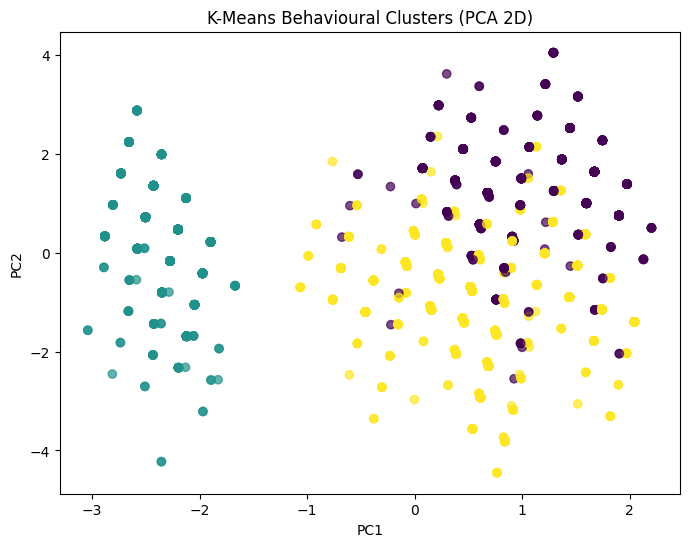

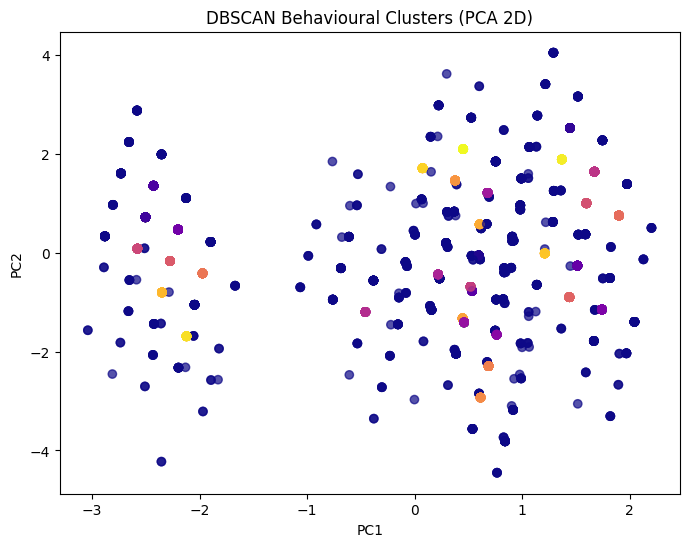


=== K-MEANS CLUSTER PROFILES ===
         selfconf    aiconf  confidence_shift  pre_accuracy  post_accuracy  \
cluster                                                                      
0        0.439851  0.524505          0.084653      0.000000            1.0   
1        0.418790  0.527335          0.108546      0.032909            0.0   
2        0.527797  0.547307          0.019510      1.000000            1.0   

         accuracy_delta  reliance_index  feedback2  
cluster                                             
0              1.000000        0.965347   0.683168  
1             -0.032909        0.000000  -5.000000  
2              0.000000        0.580110   1.526243  

=== DBSCAN CLUSTER PROFILES (noise = -1) ===
         selfconf    aiconf  confidence_shift  pre_accuracy  post_accuracy  \
cluster                                                                      
-1       0.449912  0.533098          0.083186      0.526037       0.795234   
 0       0.500000  0.750000   

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt


df = pd.read_csv("clean_df.csv")
features = [
    "selfconf", "aiconf", "confidence_shift",
    "pre_accuracy", "post_accuracy",
    "accuracy_delta", "reliance_index", "feedback2"
]

X = df[features].copy()
X = X.dropna()

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# PCA for Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


# K-MEANS CLUSTERING
kmeans = KMeans(n_clusters=3, random_state=42)
clusters_k = kmeans.fit_predict(X_scaled)

df_k = X.copy()
df_k["cluster"] = clusters_k

# DBSCAN CLUSTERING
dbscan = DBSCAN(eps=0.7, min_samples=30)
clusters_db = dbscan.fit_predict(X_scaled)

df_db = X.copy()
df_db["cluster"] = clusters_db

# PLOTS (K-Means)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_k, cmap="viridis", alpha=0.7)
plt.title("K-Means Behavioural Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# PLOTS (DBSCAN)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_db, cmap="plasma", alpha=0.7)
plt.title("DBSCAN Behavioural Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# CLUSTER PROFILES
print("\n=== K-MEANS CLUSTER PROFILES ===")
print(df_k.groupby("cluster").mean())

print("\n=== DBSCAN CLUSTER PROFILES (noise = -1) ===")
print(df_db.groupby("cluster").mean())


In [ ]:
new_df

,opponent_move,allgoodmoves,initial_move,ai_suggestion,ai_suggestion_ranking,final_move,feedback1,feedback2,selfconf,aiconf,fen before white move,fen before black move,confidence_shift,pre_accuracy,post_accuracy,accuracy_delta,reliance_index
0,unknown,unknown,unknown,unknown,1.0,unknown,-5.0,-5.0,0.50,0.75,unknown,unknown,0.25,1,1,0,1
1,c4d5,"[[599, 437, 437, 435, 354, -53, -68], ['g4h4',...",e4f6,g4h4,1.0,g4h4,-5.0,5.0,0.25,0.75,rn5k/1p4b1/pr1p4/2pPpp2/2b1N1Q1/6P1/PP1N1P1P/R...,rn5k/1p4b1/pr1p4/2pbpp2/4N1Q1/6P1/PP1N1P1P/R5K...,0.50,0,1,1,1
2,c3a1,"[[1072, 620, 620, 86, -40, -40, -282], ['f3f6'...",h1h2,f3h5,7.0,h1h2,-5.0,-5.0,0.25,0.50,r5rk/2p1Np2/3p3P/4p1P1/4P3/2qnPQK1/8/R6R b - -...,r5rk/2p1Np2/3p3P/4p1P1/4P3/3nPQK1/8/q6R w - - 1 0,0.25,0,0,0,0
3,c8g4,"[[823, 361, 361, 150, 67, -27, -59], ['f3f8', ...",h6f8,f3f8,1.0,f3g3,-5.0,-5.0,0.00,0.50,rnb3k1/ppp4p/3b3B/3Pp3/2BP4/4KRp1/PPP3q1/RN1Q4...,rn4k1/ppp4p/3b3B/3Pp3/2BP2b1/4KRp1/PPP3q1/RN1Q...,0.50,0,0,0,0
4,c8c7,"[[898, 32, 32, -53, -364, -447, -477], ['b6a6'...",b6c6,b6a6,1.0,b6a6,5.0,5.0,0.00,0.75,2k4r/1r1q2pp/1Rp2p2/1p6/8/Q7/P4PPP/2R3K1 b - -...,7r/1rkq2pp/1Rp2p2/1p6/8/Q7/P4PPP/2R3K1 w - - 1 0,0.75,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3395,d8a5,"[[342, 217, 15, 15, -49, -73, -104], ['f2f3', ...",g6e8,f2f3,1.0,g6e8,-5.0,-5.0,0.50,0.25,r2qrk2/p5p1/2b1p1Q1/1p1pP3/2p1nB2/2P1P3/PP3P2/...,r3rk2/p5p1/2b1p1Q1/qp1pP3/2p1nB2/2P1P3/PP3P2/2...,-0.25,0,0,0,0
3396,a8a7,"[[507, 210, 13, -59, -107, -109, -438], ['h7g6...",f4f8,h7g6,1.0,h7g8,-5.0,-5.0,0.50,0.25,r3r3/7B/2p1b3/ppk5/5R2/P2P3p/1PP4R/1K6 b - - 0 1,4r3/r6B/2p1b3/ppk5/5R2/P2P3p/1PP4R/1K6 w - - 1 0,-0.25,0,0,0,0
3397,b4c3,"[[161, 156, 100, -15, -213, -253, -254], ['a1b...",h6h7,a1b1,1.0,h6h7,-5.0,-5.0,0.50,0.25,r1r3k1/pp1q1p1p/4nBpQ/3pP3/1b5P/3B4/P1N3P1/R2K...,r1r3k1/pp1q1p1p/4nBpQ/3pP3/7P/2bB4/P1N3P1/R2K3...,-0.25,0,0,0,0
3398,h7g6,"[[20, 18, 3, 0, -15, -31, -49], ['h2h3', 'h2h3...",f3f5,e3d2,7.0,f3f5,-5.0,-5.0,0.50,0.00,4r3/6kp/ppr1b1P1/3p4/3Pq3/3nBR2/PP4QP/6RK b - ...,4r3/6k1/ppr1b1p1/3p4/3Pq3/3nBR2/PP4QP/6RK w - ...,-0.50,0,0,0,0


In [ ]:
new_df.describe()

,ai_suggestion_ranking,feedback1,feedback2,selfconf,aiconf,confidence_shift,pre_accuracy,post_accuracy,accuracy_delta,reliance_index
count,3400.000000,3400.000000,3400.000000,3400.000000,3400.000000,3400.000000,3400.00000,3400.000000,3400.000000,3400.000000
mean,3.823529,-2.070588,-0.532353,0.471471,0.535000,0.063529,0.43500,0.722941,0.287941,0.533824
std,2.995246,4.551786,4.972311,0.237737,0.253881,0.302134,0.49583,0.447612,0.472580,0.498928
min,1.000000,-5.000000,-5.000000,0.000000,0.000000,-1.000000,0.00000,0.000000,-1.000000,0.000000
25%,1.000000,-5.000000,-5.000000,0.250000,0.500000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,1.000000,-5.000000,-5.000000,0.500000,0.500000,0.000000,0.00000,1.000000,0.000000,1.000000
75%,7.000000,5.000000,5.000000,0.500000,0.750000,0.250000,1.00000,1.000000,1.000000,1.000000
max,7.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000


In [ ]:


new_df[new_df['post_accuracy'] == 0].describe()

,ai_suggestion_ranking,feedback1,feedback2,selfconf,aiconf,confidence_shift,pre_accuracy,post_accuracy,accuracy_delta,reliance_index
count,942.000000,942.000000,942.0,942.000000,942.000000,942.000000,942.000000,942.0,942.000000,942.0
mean,3.993631,-4.745223,-5.0,0.418790,0.527335,0.108546,0.032909,0.0,-0.032909,0.0
std,3.001587,1.576546,0.0,0.226235,0.250629,0.306611,0.178492,0.0,0.178492,0.0
min,1.000000,-5.000000,-5.0,0.000000,0.000000,-1.000000,0.000000,0.0,-1.000000,0.0
25%,1.000000,-5.000000,-5.0,0.250000,0.250000,0.000000,0.000000,0.0,0.000000,0.0
50%,1.000000,-5.000000,-5.0,0.500000,0.500000,0.000000,0.000000,0.0,0.000000,0.0
75%,7.000000,-5.000000,-5.0,0.500000,0.750000,0.250000,0.000000,0.0,0.000000,0.0
max,7.000000,5.000000,-5.0,1.000000,1.000000,1.000000,1.000000,0.0,0.000000,0.0


In [ ]:
new_df[new_df['post_accuracy'] == 1].describe()

,ai_suggestion_ranking,feedback1,feedback2,selfconf,aiconf,confidence_shift,pre_accuracy,post_accuracy,accuracy_delta,reliance_index
count,2458.000000,2458.000000,2458.000000,2458.000000,2458.000000,2458.000000,2458.000000,2458.0,2458.000000,2458.000000
mean,3.758340,-1.045566,1.179821,0.491660,0.537937,0.046277,0.589097,1.0,0.410903,0.738405
std,2.990859,4.890452,4.859797,0.238985,0.255106,0.298670,0.492098,0.0,0.492098,0.439593
min,1.000000,-5.000000,-5.000000,0.000000,0.000000,-1.000000,0.000000,1.0,0.000000,0.000000
25%,1.000000,-5.000000,-5.000000,0.250000,0.500000,0.000000,0.000000,1.0,0.000000,0.000000
50%,1.000000,-5.000000,5.000000,0.500000,0.500000,0.000000,1.000000,1.0,0.000000,1.000000
75%,7.000000,5.000000,5.000000,0.750000,0.750000,0.250000,1.000000,1.0,1.000000,1.000000
max,7.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
